In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats.mstats import winsorize
import seaborn as sns

In [2]:
xls = pd.ExcelFile('data/srcsc-2026-claims-equipment-failure.xlsx')
xls.sheet_names

['freq', 'sev']

In [3]:
df_equipment_failure_freq = pd.read_excel(xls, sheet_name='freq')
df_equipment_failure_freq.head()

,policy_id,equipment_id,equipment_type,equipment_age,solar_system,maintenance_int,usage_int,exposure,claim_count
0,EF-105325,EQ-722288,ReglAggregators,8.061,Epsilon,193.08,19.12,0.874,0.0
1,EF-136959,EQ-961161,Flux Rider,14.722,Epsilon,715.35,16.07,0.467,1.0
2,EF-045457,EQ-626201,Graviton Extractor,14.411,Epsilon,391.95,22.60,0.615,0.0
3,EF-533949,EQ-967143,ReglAggregators,4.655,Zeta,1466.51,5.04,0.423,0.0
4,EF-968417,EQ-796533,Flux Rider,20.346,Zeta,1268.96,20.47,0.769,0.0


In [4]:
df_equipment_failure_sev = pd.read_excel(xls, sheet_name='sev')
df_equipment_failure_sev.head()

,claim_id,claim_seq,policy_id,equipment_id,equipment_type,equipment_age,solar_system,maintenance_int,usage_int,exposure,claim_amount
0,EF-C-0000001,1.0,EF-136959,EQ-961161,Flux Rider,14.722,Epsilon,715.35,16.07,0.467,49193.0
1,EF-C-0000002,1.0,EF-117340,EQ-651029,ReglAggregators,13.624,Helionis Cluster,530.77,4.10,0.372,73688.0
2,EF-C-0000003,1.0,EF-608351,EQ-094886,ReglAggregators,12.779,Zeta,635.16,10.23,0.701,50797.0
3,EF-C-0000004,1.0,EF-786159,EQ-654494,Quantum Bore,6.752,Zeta,572.54,10.44,0.643,213915.0
4,EF-C-0000005,1.0,EF-364736,EQ-425368,ReglAggregators,13.761,Helionis Cluster,426.02,21.81,0.601,29713.0


In [5]:
common_cols=set(df_equipment_failure_freq.columns).intersection(set(df_equipment_failure_sev.columns))
print("Common columns:", common_cols)
uncommon_cols_freq = set(df_equipment_failure_freq.columns) - common_cols
print("Uncommon columns in freq:", uncommon_cols_freq)
uncommon_cols_sev = set(df_equipment_failure_sev.columns) - common_cols
print("Uncommon columns in sev:", uncommon_cols_sev)

Common columns: {'equipment_type', 'exposure', 'usage_int', 'maintenance_int', 'policy_id', 'equipment_age', 'equipment_id', 'solar_system'}
Uncommon columns in freq: {'claim_count'}
Uncommon columns in sev: {'claim_id', 'claim_seq', 'claim_amount'}


In [7]:
def initial_cleaning(df):
    df = df.copy()  # Avoid modifying original dataframe
    """Clean and preprocess equipment failure dataframe."""
    # Basic info
    print(df.info())

    # Missing values analysis
    rows_with_nulls = df.isnull().any(axis=1).sum()
    rows_null_pct = (rows_with_nulls / df.shape[0]) * 100
    print(f"\nRows with nulls: {rows_with_nulls} ({rows_null_pct:.2f}%)")
    # Drop nulls and update dataframe in place
    if rows_null_pct <= 5:
        df.dropna(inplace=True)
        print(f"\nShape after removing nulls: {df.shape}")

    # Clean categorical columns
    cat_cols = df.select_dtypes(include=["object", "str"]).columns
    print(f"\nCategorical columns: {cat_cols}")
    num_cols = df.select_dtypes(include=[np.number]).columns
    print(f"Numerical columns: {num_cols}")
    unique_cols = ["solar_system", "equipment_type"]
    for col in unique_cols:
        print(f"\nUnique values in '{col}' (before): {df[col].unique()}")
        df[col] = df[col].str.extract(r"^([A-Za-z\s]+)")
        print(f"Unique values in '{col}' (after): {df[col].unique()}")

    # Ranges:
    # equipment_age 0-10
    # maintenance_int 100-5000
    # usage_int 0-24
    # exposure 0-1
    # claim_count 0-3
    df_filtered = df[
        (df["equipment_age"] >= 0)
        & (df["equipment_age"] <= 10)
        & (df["maintenance_int"] >= 100)
        & (df["maintenance_int"] <= 5000)
        & (df["usage_int"] >= 0)
        & (df["usage_int"] <= 24)
        & (df["exposure"] >= 0)
        & (df["exposure"] <= 1)
    ]
    df_filtered = df_filtered.astype(
        {
            "equipment_type": "category",
            "solar_system": "category",
        }
    )
    if "claim_count" in df_filtered.columns:
        df_filtered = df_filtered[
            (df_filtered["claim_count"] >= 0) & (df_filtered["claim_count"] <= 3)
        ]
    if "claim_amount" in df_filtered.columns:
        print(df_filtered.dtypes)
        # df_filtered = df_filtered[
        #     df_filtered["claim_seq"] >= 0 & df_filtered["claim_seq" <= 3] & df_filtered["claim_amount"] >= 0
        # ]

    print(f"\nShape after applying range filters: {df_filtered.shape}")

    return df_filtered

In [8]:
df_equipment_failure_freq_filtered = initial_cleaning(df_equipment_failure_freq)

<class 'pandas.DataFrame'>
RangeIndex: 95062 entries, 0 to 95061
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   policy_id        94838 non-null  str    
 1   equipment_id     94841 non-null  str    
 2   equipment_type   94823 non-null  str    
 3   equipment_age    94918 non-null  float64
 4   solar_system     94828 non-null  str    
 5   maintenance_int  94908 non-null  float64
 6   usage_int        94921 non-null  float64
 7   exposure         94937 non-null  float64
 8   claim_count      94887 non-null  float64
dtypes: float64(5), str(4)
memory usage: 6.5 MB
None

Rows with nulls: 1641 (1.73%)

Shape after removing nulls: (93421, 9)

Categorical columns: Index(['policy_id', 'equipment_id', 'equipment_type', 'solar_system'], dtype='str')
Numerical columns: Index(['equipment_age', 'maintenance_int', 'usage_int', 'exposure',
       'claim_count'],
      dtype='str')

Unique values in 'solar_system' (befo

In [9]:
df_equipment_failure_sev_filtered = initial_cleaning(df_equipment_failure_sev)

<class 'pandas.DataFrame'>
RangeIndex: 8272 entries, 0 to 8271
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   claim_id         8244 non-null   str    
 1   claim_seq        8259 non-null   float64
 2   policy_id        8250 non-null   str    
 3   equipment_id     8257 non-null   str    
 4   equipment_type   8238 non-null   str    
 5   equipment_age    8262 non-null   float64
 6   solar_system     8257 non-null   str    
 7   maintenance_int  8260 non-null   float64
 8   usage_int        8263 non-null   float64
 9   exposure         8259 non-null   float64
 10  claim_amount     8256 non-null   float64
dtypes: float64(6), str(5)
memory usage: 711.0 KB
None

Rows with nulls: 186 (2.25%)

Shape after removing nulls: (8086, 11)

Categorical columns: Index(['claim_id', 'policy_id', 'equipment_id', 'equipment_type',
       'solar_system'],
      dtype='str')
Numerical columns: Index(['claim_seq', 'equipment_

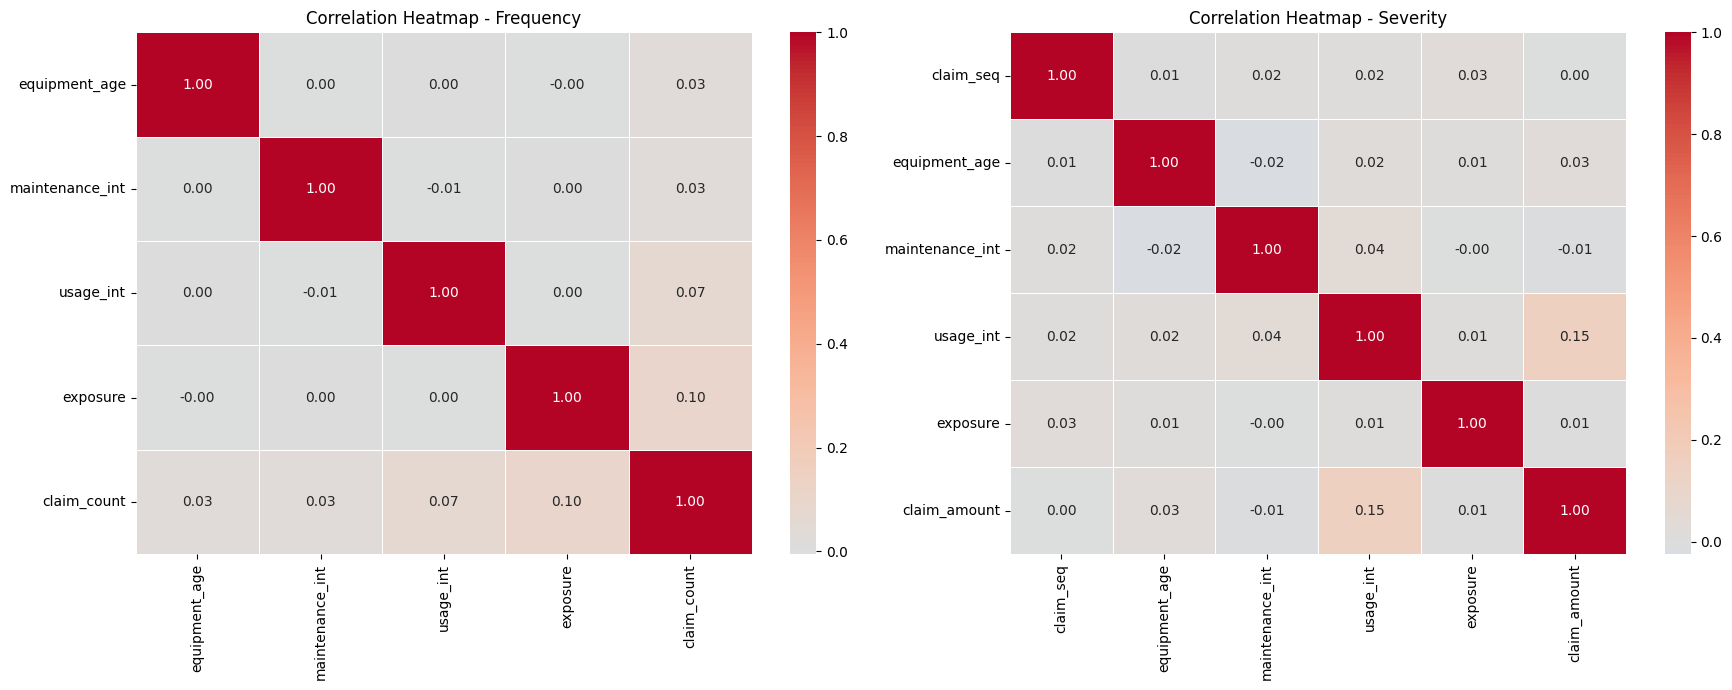

In [10]:
freq_corr = df_equipment_failure_freq_filtered.select_dtypes(include="number").corr()
sev_corr = df_equipment_failure_sev_filtered.select_dtypes(include="number").corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(freq_corr, ax=axes[0], cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
axes[0].set_title("Correlation Heatmap - Frequency")

sns.heatmap(sev_corr, ax=axes[1], cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
axes[1].set_title("Correlation Heatmap - Severity")

plt.tight_layout()

In [12]:
# output_path = "data_filtered/filtered_equipment_failure.xlsx"

# with pd.ExcelWriter(output_path) as writer:
#     df_equipment_failure_freq_filtered.to_excel(writer, sheet_name="freq", index=False)
#     df_equipment_failure_sev_filtered.to_excel(writer, sheet_name="sev", index=False)

# print(f"Saved filtered data to {output_path}")

Saved filtered data to data_filtered/filtered_equipment_failure.xlsx


In [ ]:
df = df_equipment_failure_freq_filtered.copy()

In [ ]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df_wins = df.copy()
numeric_cols = df_wins.select_dtypes(include=[np.number]).columns
# for col in numeric_cols:
#     df_wins[col] = np.asarray(winsorize(df_wins[col], limits=[0.01, 0.01]))

df_sample = df_wins.sample(n=min(2000, len(df_wins)), random_state=42)

sns.pairplot(
    df_sample,
    vars=numeric_cols,
    hue="solar_system",
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 10, "edgecolor": "none"},
)
plt.suptitle("Pairwise Scatter Plots by Solar System", y=1.02)
plt.show()

# EXTRA

In [ ]:
df_equipment_failure_freq = df_equipment_failure_freq_filtered

In [ ]:
def outliers_remover(system_df, numeric_cols, solar_system):
    # Remove outliers (IQR method)
    filtered_df = system_df.copy()
    for col in numeric_cols:
        q1, q3 = filtered_df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        filtered_df = filtered_df[(filtered_df[col] >= q1 - 1.5*iqr) & (filtered_df[col] <= q3 + 1.5*iqr)]
    plot_scatter_matrix(filtered_df, f'Scatter Plot Matrix for {solar_system} Solar System (Outliers Removed)')
    return filtered_df

def logged_pairgrid(system_df, solar_system):
    # Log-transformed PairGrid
    df_log = system_df.copy()
    for col in ['equipment_age', 'maintenance_int', 'usage_int', 'exposure']:
        df_log[col] = np.log1p(df_log[col])
    
    g = sns.PairGrid(df_log, diag_sharey=False)
    g.map_offdiag(sns.scatterplot, s=10, alpha=0.2, edgecolor=None)
    g.map_diag(sns.histplot, kde=True, color='steelblue')
    g.figure.suptitle(f'Log-Transformed Feature Matrix: {solar_system} Solar System', y=0.99)
    plt.show()

def winsorized_pairgrid(system_df, solar_system):
    # Winsorize and visualize
    df_wins = system_df.copy()
    for col in ['equipment_age', 'maintenance_int', 'usage_int', 'exposure']:
        df_wins[col] = winsorize(df_wins[col], limits=[0.01, 0.01])
    
    print("Data successfully capped at 1st and 99th percentiles.")
    plot_scatter_matrix(df_wins, f'Scatter Plot Matrix for {solar_system} Solar System (Winsorized)')
    return df_wins

# Plot scatter matrix helper
def plot_scatter_matrix(data, title, figsize=(20, 20)):
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    n = len(numeric_cols)
    fig, axes = plt.subplots(n, n, figsize=figsize)
    fig.suptitle(title, fontsize=20, y=0.995)
    
    for i, col_y in enumerate(numeric_cols):
        for j, col_x in enumerate(numeric_cols):
            ax = axes[i, j]
            if i == j:
                ax.hist(data[col_x], bins=30, edgecolor='black', alpha=0.7)
            else:
                ax.scatter(data[col_x], data[col_y], alpha=0.3, s=10)
            
            if i == n - 1:
                ax.set_xlabel(col_x.replace('_', ' ').title(), fontsize=10)
            if j == 0:
                ax.set_ylabel(col_y.replace('_', ' ').title(), fontsize=10)
            if i < n - 1:
                ax.set_xticklabels([])
            if j > 0:
                ax.set_yticklabels([])
    
    plt.tight_layout()
    plt.show()

def hexbin_plots(system_df, numeric_cols, solar_system):
    n = len(numeric_cols)
    fig, axes = plt.subplots(n, n, figsize=(20, 20))
    fig.suptitle(f'Hexbin Plot Matrix for {solar_system} Solar System', fontsize=20, y=0.995)
    
    for i, col_y in enumerate(numeric_cols):
        for j, col_x in enumerate(numeric_cols):
            ax = axes[i, j]
            if i == j:
                ax.hist(system_df[col_x], bins=30, edgecolor='black', alpha=0.7)
            else:
                hb = ax.hexbin(system_df[col_x], system_df[col_y], gridsize=20, cmap='YlOrRd', mincnt=1)
                plt.colorbar(hb, ax=ax, label='Count')
            
            if i == n - 1:
                ax.set_xlabel(col_x.replace('_', ' ').title(), fontsize=10)
            if j == 0:
                ax.set_ylabel(col_y.replace('_', ' ').title(), fontsize=10)
            if i < n - 1:
                ax.set_xticklabels([])
            if j > 0:
                ax.set_yticklabels([])
    plt.tight_layout()
    plt.show()

def density_optimized_pairgrid(df_wins, solar_system):
    # Density-optimized PairGrid
    df_sample = df_wins.sample(n=min(2000, len(df_wins)), random_state=42)
    g = sns.PairGrid(df_sample, diag_sharey=False)
    g.map_diag(sns.kdeplot, fill=True, color="steelblue")
    g.map_offdiag(sns.scatterplot, alpha=0.1, s=5, color="steelblue", edgecolor=None)
    g.figure.suptitle(f'Density-Optimized Matrix: {solar_system} Solar System (Winsorized)', y=1.02)
    plt.show()

def trend_analysis_pairgrid(df_wins, solar_system):
    # Trend analysis
    df_sample = df_wins.sample(n=min(1000, len(df_wins)), random_state=42)
    g = sns.PairGrid(df_sample, diag_sharey=False)
    g.map_diag(sns.kdeplot, fill=True, color="steelblue", alpha=0.5)
    g.map_offdiag(sns.regplot, scatter_kws={'alpha': 0.1, 's': 10, 'color': 'steelblue'}, 
                  line_kws={'color': 'darkorange', 'lw': 2})
    g.figure.suptitle(f'Trend Analysis Matrix: {solar_system} Solar System', y=1.02)
    plt.show()

def solar_system_analysis(df, solar_system):
    system_df = df[df['solar_system'] == solar_system]
    equipment_types = system_df['equipment_type'].unique()
    
    print(f"Number of records for {solar_system}: {len(system_df)}")
    # print(f"Equipment types in {solar_system}:", equipment_types)
    print(f"\nSummary statistics for {solar_system}:")
    display(system_df.describe(include='all'))
    
    numeric_cols = ['equipment_age', 'maintenance_int', 'usage_int', 'exposure', 'claim_count']
    
    # Visualize by equipment type
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Claim Count Distribution by Equipment Type - {solar_system}', fontsize=16)
    
    for idx, eq_type in enumerate(axes.flatten()):
        if idx < len(equipment_types):
            eq_df = system_df[system_df['equipment_type'] == equipment_types[idx]]
            axes.flatten()[idx].hist(eq_df['claim_count'], bins=20, edgecolor='black')
            axes.flatten()[idx].set_title(f'{equipment_types[idx]}\n(n={len(eq_df)})')
        axes.flatten()[idx].set_xlabel('Claim Count')
        axes.flatten()[idx].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # Original data
    plot_scatter_matrix(system_df, f'Scatter Plot Matrix for {solar_system} Solar System')
    
    # Remove outliers (IQR method)
    # filtered_df = outliers_remover(system_df, numeric_cols, solar_system)
    
    # Log-transformed PairGrid
    logged_pairgrid(system_df, solar_system)
    
    # Violin plot
    # plt.figure(figsize=(18, 6))
    # sns.violinplot(data=system_df, x='claim_count', y='maintenance_int', inner="quart")
    # plt.title('Distribution Shape: Maintenance vs Claims')
    # plt.show()
    
    # Winsorization
    df_wins = winsorized_pairgrid(system_df, solar_system)
    
    # Hexbin plot
    hexbin_plots(df_wins, numeric_cols, solar_system)
    
    # Density-optimized PairGrid
    density_optimized_pairgrid(df_wins, solar_system)
    
    # Trend analysis
    trend_analysis_pairgrid(df_wins, solar_system)

In [ ]:
solar_system_analysis(df_equipment_failure_freq, 'Zeta')

In [ ]:
solar_system_analysis(df_equipment_failure_freq, 'Epsilon')